# Eksperiment 2-10 — Razlika formi (EMA 50%)



In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from experiment_utils import save_result_v1, run_one_experiment, run, MLPClassifier

In [2]:
FEATURE_COLS = ["form_diff_ema50"]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")
data = data.dropna(subset=FEATURE_COLS + ["result"])

X = data[FEATURE_COLS].values.astype(np.float32)
y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)



In [3]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0118 | val loss = 0.9295 | val acc = 0.5955
Epoch 100/1000 | train loss = 1.0098 | val loss = 0.9354 | val acc = 0.5899
Epoch 150/1000 | train loss = 1.0130 | val loss = 0.9366 | val acc = 0.5899
Epoch 200/1000 | train loss = 1.0105 | val loss = 0.9342 | val acc = 0.5843
Epoch 250/1000 | train loss = 1.0075 | val loss = 0.9312 | val acc = 0.5843
Epoch 300/1000 | train loss = 1.0091 | val loss = 0.9292 | val acc = 0.5843
Epoch 350/1000 | train loss = 1.0140 | val loss = 0.9331 | val acc = 0.5899
Epoch 400/1000 | train loss = 1.0097 | val loss = 0.9331 | val acc = 0.5899
Epoch 450/1000 | train loss = 1.0058 | val loss = 0.9294 | val acc = 0.5899
Epoch 500/1000 | train loss = 1.0109 | val loss = 0.9253 | val acc = 0.5955
Epoch 550/1000 | train loss = 1.0134 | val loss = 0.9340 | val acc = 0.5955
Epoch 600/1000 | train loss = 1.0100 | val loss = 0.9346 | val acc = 0.5955
Epoch 650/1000 | train loss = 1.0109 | val loss = 0.9342 | val acc = 0.5955
Epoch 700/100

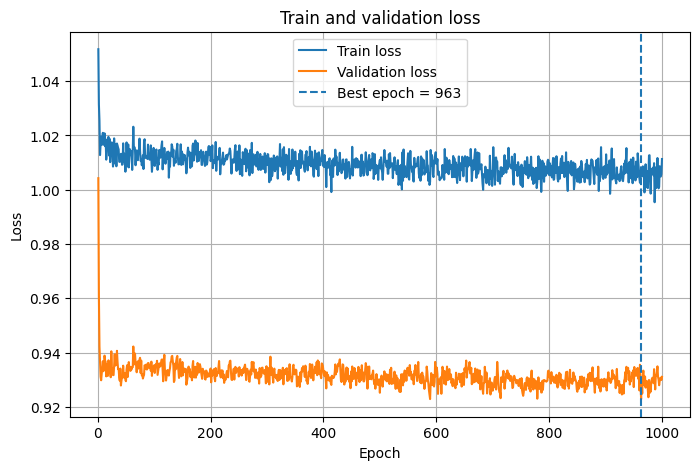

0.5225225225225225

In [4]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

## Trening (10 run-ova)

In [5]:
best_num_epochs = 963

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5225 | Precision: 0.3331 | Recall: 0.4517 | Specificity: 0.7296 | F1: 0.3804

Run 2/10
Accuracy: 0.5225 | Precision: 0.3387 | Recall: 0.4460 | Specificity: 0.7248 | F1: 0.3780

Run 3/10
Accuracy: 0.5315 | Precision: 0.3544 | Recall: 0.4525 | Specificity: 0.7264 | F1: 0.3864

Run 4/10
Accuracy: 0.5180 | Precision: 0.3347 | Recall: 0.4428 | Specificity: 0.7228 | F1: 0.3749

Run 5/10
Accuracy: 0.5225 | Precision: 0.3408 | Recall: 0.4460 | Specificity: 0.7240 | F1: 0.3786

Run 6/10
Accuracy: 0.5180 | Precision: 0.3289 | Recall: 0.4456 | Specificity: 0.7268 | F1: 0.3751

Run 7/10
Accuracy: 0.5225 | Precision: 0.3387 | Recall: 0.4460 | Specificity: 0.7248 | F1: 0.3780

Run 8/10
Accuracy: 0.5225 | Precision: 0.3430 | Recall: 0.4460 | Specificity: 0.7232 | F1: 0.3793

Run 9/10
Accuracy: 0.5180 | Precision: 0.3329 | Recall: 0.4428 | Specificity: 0.7236 | F1: 0.3743

Run 10/10
Accuracy: 0.5180 | Precision: 0.3347 | Recall: 0.4428 | Specificity: 0.7228 | F1: 0.3749

Summary o

In [7]:
save_result_v1(
    experiment_name="Experiment_2-10_EMA50_diff",
    summary=summary
)


Saved result for Experiment_2-10_EMA50_diff
File: ../results/experiment_summary_v1.csv
